In [1]:
from IPython.display import Image, display
import operator
from typing import Annotated, List, Literal, TypedDict
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, interrupt
from langchain_core.messages import (
    HumanMessage,
    AIMessage,
models_anthropicolMessage,
    SystemMessage,
)
from langgraph.graph.message import add_messages
from typing_extensions import Annotated
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
from pydantic import BaseModel, Field
from pathlib import Path

In [2]:
from models import model_1, model_2
import os
api_key= os.environ['API_ATHROPIC_ROUTER']


In [3]:
####DATA
#SCHEDULE
from datetime import datetime
now = datetime.now()
import pandas as pd
schedule_path = '/Users/phamgiahung/Documents/project_AI/langgraph_agent/data/schedule.csv'
schedule = pd.read_csv(schedule_path,index_col= 'date')

#MEMORY
memory_path= "/Users/phamgiahung/Documents/project_AI/langgraph_agent/data/memory.txt"


In [4]:
#TOOL

def r_memory():
    with open(memory_path,'r', encoding ="utf-8") as f:
        knowledge = f.read()
    return knowledge
@tool
def w_memory(knowledge: str) -> str:
    ''' add knowlege into model's memory '''
    with open(memory_path,'a', encoding ="utf-8") as f:
        f.write("\n"+knowledge)
    return " Đã viết thành công"
@tool
def w_pd(date: datetime, content: str) -> str:
    """
    Thêm nội dung vào lịch trình cá nhân tại một ngày cụ thể.

    Tool này dùng để GHI hoặc CẬP NHẬT lịch trình cá nhân trong schedule.csv.

    Args:
        date:
            Ngày cần ghi lịch trình.
            Chỉ dùng ngày/thời gian mà người dùng đã cung cấp hoặc đã được
            xác định rõ từ ngữ cảnh. Không tự ý tạo ngày nếu chưa đủ thông tin.

        content:
            Nội dung lịch trình cần thêm vào ngày đó.
            Nội dung mới sẽ được nối thêm vào nội dung đã có của ngày,
            không ghi đè nội dung cũ.

    Returns:
        Thông báo xác nhận việc ghi lịch thành công.

    Notes:
        - Nếu ngày chưa tồn tại trong lịch, một mục mới sẽ được tạo.
        - Nếu ngày đã tồn tại, nội dung mới được thêm vào nội dung hiện có.
        - Tool này dùng cho dữ liệu lịch trình cá nhân, không phải để lưu
          kiến thức chung hoặc memory của model.
    """

    global schedule
    date= pd.Timestamp(date)

    if date not in schedule.index:
        schedule.loc[date, "content"] = ""

    schedule.loc[date, "content"] += content +"\n"
    schedule.index = pd.to_datetime(schedule.index)
    schedule= schedule.sort_index()
    
    

    return "Đã viết lịch trình thành công."


@tool
def read_pd(datetime_from: datetime, datetime_to: datetime) -> dict:
    """
    Đọc lịch trình cá nhân trong một khoảng thời gian.

    Tool này dùng để TRA CỨU các sự kiện, công việc hoặc nội dung lịch trình
    đã được lưu trong schedule.csv.

    Args:
        datetime_from:
            Thời điểm bắt đầu của khoảng thời gian cần đọc.

        datetime_to:
            Thời điểm kết thúc của khoảng thời gian cần đọc.

    Returns:
        Dictionary có dạng:
        {
            datetime: "nội dung lịch trình"
        }

        Mỗi key là một ngày/thời điểm trong khoảng được yêu cầu,
        value là nội dung lịch trình tương ứng.

    Notes:
        - Chỉ đọc dữ liệu đã có trong lịch trình.
        - Không tự tạo hoặc suy diễn sự kiện chưa được lưu.
        - Dùng tool này khi cần kiểm tra lịch, tìm sự kiện,
          hoặc lấy thông tin lịch trình để lập kế hoạch.
        - Nếu người dùng hỏi về lịch trong một khoảng thời gian,
          hãy truyền đúng khoảng thời gian đó thay vì đọc toàn bộ lịch.
    """
    global schedule
    schedule.index = pd.to_datetime(schedule.index)
    schedule= schedule.sort_index()
    datetime_from = pd.Timestamp(datetime_from)
    datetime_to   = pd.Timestamp(datetime_to)
    content = schedule.loc[datetime_from:datetime_to]
    if content.empty:
        return {
            "status": "success",
            "message": "Không có lịch trình nào trong khoảng thời gian này.",
            "data": {}
        }


    content_dict = {}

    for date in content.index:
        content_dict[date] = content.loc[date, "content"]

    return {
        "status": "success",
        "data": content_dict
    }
tools= [w_pd, read_pd]
model_1= model_1.bind_tools(tools)
model_2= model_2.bind_tools(tools)

In [5]:
from pydantic import BaseModel, Field
class State(TypedDict):
    #INPUT
    knowledge: str
    user_input: str
    messages: Annotated[List[str], add_messages]
    current_time: datetime
    #PLAN
    plan: List[str]
    #EXECUTION
    work_memory: Annotated[List[str],operator.add]
    last_work: List[str]
    time_call: int
    max_call: int
    #OBSERVATION / EVALUATION
    confidence: int
    feedback: Annotated[List[str], operator.add]
    retry: int
    final_output: str
    #Memorize
    last_work_memo: List[str]
    
class evaluation_model(BaseModel):
    feedback: List[str]
    confidence: float = Field(ge=0, le=1)
    approved: bool
    final_output: str





In [6]:
def extract_tool_result(response):
    result =[]
    for message in response:
        if isinstance(message, ToolMessage):
            result.append(message)
    return result


In [8]:
def planner(state: State):
    SYSTEM_PROMPT = """
    Bạn là PLANNER của một AI Agent.

    NHIỆM VỤ:
    Phân tích yêu cầu của người dùng và xây dựng một kế hoạch thực hiện
    rõ ràng, có thứ tự.

    NGUYÊN TẮC:
    1. Xác định chính xác mục tiêu mà người dùng muốn đạt được.
    2. Chia vấn đề thành các bước nhỏ nếu cần.
    3. Xác định thông tin nào đã có và thông tin nào còn thiếu.
    4. Xác định bước nào cần sử dụng tool.
    5. Không tự thực hiện công việc của Executor.
    6. Không tạo ra thông tin không có trong Knowledge.
    7. Kế hoạch phải có thể được Executor thực hiện tuần tự.
    8. Nếu vấn đề đơn giản, tạo kế hoạch ngắn gọn thay vì phức tạp hóa.

    OUTPUT:
    - Mục tiêu
    - Các bước thực hiện theo thứ tự
    - Tool cần sử dụng (nếu có)
    - Điều kiện để coi nhiệm vụ hoàn thành
    """

    PROMPT = f"""
    {SYSTEM_PROMPT}

    VẤN ĐỀ NGƯỜI DÙNG:
    {state['user_input']}

    KIẾN THỨC HIỆN CÓ:
    {state['knowledge']}

    THỜI GIAN HIỆN TẠI:
    {state['current_time']}
    """

    response = model_1.invoke(PROMPT)
    plan= response.content
    
    print(" ===============PLANNER================")
    print("Plan:", plan)
    return {
        "plan": plan
    }

In [9]:
tool_node = ToolNode(tools)
def executor(state: State) -> Command[Literal["tool", "observation"]]:

    SYSTEM_PROMPT = """
    Bạn là EXECUTOR của một AI Agent.

    NHIỆM VỤ:
    Thực hiện kế hoạch đã được Planner tạo ra để giải quyết vấn đề của
    người dùng.

    NGUYÊN TẮC:

    1. Tuân thủ kế hoạch nhưng có thể điều chỉnh nếu kết quả thực tế
       cho thấy kế hoạch cần thay đổi.

    2. Không bỏ qua thông tin quan trọng trong work_memory hoặc feedback.

    3. Khi cần dữ liệu bên ngoài, tính toán, tra cứu hoặc thực hiện một
       hành động mà tool có thể hỗ trợ, hãy sử dụng tool thích hợp.
       Không tự bịa ra kết quả của tool.

    4. Nếu tool trả về kết quả, phải sử dụng kết quả đó trong các bước
       tiếp theo.

    5. Không gọi tool nếu thông tin hiện tại đã đủ để giải quyết vấn đề.

    6. Nếu feedback từ Evaluator chỉ ra lỗi hoặc thiếu sót:
       - xác định nguyên nhân;
       - sửa lỗi;
       - thực hiện lại bước cần thiết;
       - không lặp lại chính xác hành động đã thất bại.

    7. Chỉ đưa ra câu trả lời cuối cùng khi đã có đủ thông tin để giải
       quyết yêu cầu.

    8. Không bịa đặt dữ liệu, nguồn, kết quả tool hoặc thông tin không
       được hỗ trợ bởi context.

    9. Nếu nhiệm vụ chưa hoàn thành nhưng cần tool → gọi tool.

    10. Nếu nhiệm vụ đã hoàn thành → tạo output cuối cùng để Evaluator
        kiểm tra.
    11.Nếu LAST WORK đã cho thấy một tool đã thực hiện thành công và kết quả đã đủ để hoàn thành bước hiện tại
       -> KHÔNG gọi lại tool đó chỉ để xác minh.
    12.TRƯỚC KHI GỌI read_pd:
    
    Nếu LAST WORK đã chứa kết quả thành công của read_pd
    với cùng datetime_from và datetime_to thì KHÔNG được gọi lại.
    
    Hãy sử dụng trực tiếp kết quả read_pd đã có.
    
    Chỉ gọi lại read_pd nếu khoảng thời gian cần đọc thay đổi
    hoặc dữ liệu lịch đã bị thay đổi sau lần đọc trước.
    13. WRITE TOOL POLICY:
    
    Sau khi w_pd thực hiện thành công:
    
    - Không được gọi lại w_pd với cùng date và content.
    - Không gọi w_pd chỉ để xác nhận rằng dữ liệu đã được ghi.
    - Nếu cần kiểm tra, sử dụng kết quả của w_pd hoặc read_pd khi thực sự cần.
    14. Nếu công cụ trả về kết quả lỗi 2 lần liên tiếp hoặc thông tin thu được đã đủ trả lời sub-task, BẮT BUỘC dừng gọi công cụ và trả ra câu trả lời.
    

    MỤC TIÊU:
    Tạo ra một output chính xác, đầy đủ và phù hợp với yêu cầu của
    người dùng.
    """

    PROMPT = f"""
    {SYSTEM_PROMPT}
    ===== MAX TOOL CALL=====
    {state['max_call']}
    ===== CURRENT TOOL CALL TIME=====
    {state['time_call']}

    ===== USER PROBLEM =====
    {state['user_input']}

    ===== PLAN =====
    {state['plan']}

    ===== WORK MEMORY =====
    {state['work_memory']}

    ===== PREVIOUS EVALUATOR FEEDBACK =====
    {state['feedback'][-1]}
    ===== LAST WORK =====
    {state['last_work']}

    ===== CURRENT TASK =====
    Hãy tiếp tục thực hiện kế hoạch từ trạng thái hiện tại.
    """

    msg = [
        SystemMessage(content=PROMPT),
    ]

    response = model_2.invoke(msg)
    last_work= state['last_work'].copy()
    last_work.append(response)
    print(" ===============EXECUTOR================")
    print(schedule)
    if isinstance(state['messages'][-1], ToolMessage):
        last_work.append(state['messages'][-1])
    if response.tool_calls and state['time_call'] <= state['max_call']:
        time_call = state['time_call']+1
        next_node = "tool"
        print("thực hiện: ")
        for tool in response.tool_calls:
            print(tool["name"])
    else:
        next_node = "observation"

    
    

    return Command(
        update={
            "messages": [response],
            "last_work": last_work,
            "time_call": time_call
        },
        goto=next_node
    )


In [10]:
def observation(state: State):
    SYSTEM_PROMPT = """
    Bạn là OBSERVATION NODE của một AI Agent.
    
    VAI TRÒ DUY NHẤT:
    Đọc kết quả làm việc mới nhất trong `last_work` và tạo ra một bản ghi
    WORK MEMORY ngắn gọn, chứa những thông tin hữu ích cho các bước làm việc tiếp theo.
    
    BẠN KHÔNG:
    - lập kế hoạch
    - quyết định bước tiếp theo
    - thực hiện tool
    - đánh giá toàn bộ agent
    - trả lời trực tiếp user
    - suy đoán thông tin không có trong last_work
    
    NHIỆM VỤ:
    
    1. ĐỌC `last_work`
       Xác định những gì thực sự đã xảy ra:
       - Executor đã làm gì?
       - Tool đã trả về gì?
       - Có dữ liệu nào đã được xác nhận?
       - Có dữ liệu nào đã thay đổi?
       - Có lỗi hoặc thất bại nào xảy ra?
    
    2. TRÍCH XUẤT THÔNG TIN CÓ GIÁ TRỊ
       Chỉ giữ lại thông tin có khả năng hữu ích cho các bước sau.
    
       ƯU TIÊN:
       - kết quả tool
       - dữ liệu đã xác nhận
       - hành động đã thực hiện
       - trạng thái hiện tại của dữ liệu
       - lỗi và nguyên nhân lỗi
       - ràng buộc hoặc phát hiện mới
       - quyết định đã được thực hiện
    
       LOẠI BỎ:
       - lời nói thừa
       - nội dung hội thoại không cần thiết
       - suy luận không có căn cứ
       - thông tin đã có nhưng không thay đổi
       - toàn bộ lịch sử làm việc
    
    3. NẾU CÓ LỖI
       Ghi lại:
       - hành động nào thất bại
       - lỗi gì
       - nguyên nhân nếu đã được xác định
    
       Không tự suy đoán nguyên nhân nếu `last_work` không cung cấp.
    
    4. NẾU KHÔNG CÓ THÔNG TIN ĐÁNG LƯU
       Trả về `NONE`.
    
    NGUYÊN TẮC:
    - Chỉ sử dụng thông tin có trong `last_work`.
    - Không hallucinate.
    - Phân biệt dữ kiện thực tế với suy luận.
    - Ưu tiên thông tin mới.
    - Viết ngắn gọn.
    - Work memory phải có tính "state": đọc vào là biết tình hình hiện tại mà không cần đọc lại toàn bộ lịch sử.
    - Không tạo plan hoặc đề xuất hành động tiếp theo.
    NGUYÊN TẮC OUTPUT:
    Chỉ trả về các dòng thông tin cần ghi nhớ.
    Không thêm tiêu đề.
    Không giải thích.
    Nếu không có thông tin đáng lưu, trả về NONE.

    OUTPUT:
    
    WORK_MEMORY:
    - <thông tin quan trọng 1>
    - <thông tin quan trọng 2>
    - ...
    
    Nếu không có gì đáng lưu:
    
    WORK_MEMORY:
    NONE
    """
    msg = [
        SystemMessage(content=SYSTEM_PROMPT),
        *state["last_work"]
    ]

    response = model_1.invoke(msg)
    print(" ===============OBVERSATION================")
    print("observation", response.content)

    return {
        "last_work": [],
        "messages": [response],
        "work_memory": [response],
        "time_call": 0
    }

In [11]:
def evaluation(state: State) -> Command[Literal["executor", "complete"]]:

    SYSTEM_PROMPT = """
    Bạn là EVALUATOR của một AI Agent.

    NHIỆM VỤ:
    Đánh giá output mới nhất của Executor dựa trên yêu cầu của người
    dùng và kế hoạch đã được Planner tạo ra.

    Hãy kiểm tra độc lập, không mặc định rằng output của Executor là đúng.

    CÁC TIÊU CHÍ ĐÁNH GIÁ:

    1. CORRECTNESS:
       Output có chính xác không?
       Có mâu thuẫn logic hoặc factual error không?

    2. COMPLETENESS:
       Output có giải quyết đầy đủ yêu cầu của người dùng không?
       Có bỏ sót một phần quan trọng nào không?

    3. PLAN COMPLIANCE:
       Executor có thực hiện đúng mục tiêu và kế hoạch không?

    4. TOOL USAGE:
       Nếu nhiệm vụ cần tool, Executor đã sử dụng tool phù hợp chưa?
       Có tự bịa kết quả thay vì sử dụng tool không?

    5. EVIDENCE:
       Các kết luận quan trọng có được hỗ trợ bởi thông tin trong
       context hoặc kết quả từ tool không?

    6. USER REQUIREMENT:
       Output có thực sự trả lời câu hỏi của người dùng hay chỉ mô tả
       cách giải quyết?

    CONFIDENCE:

    confidence là mức độ tin tưởng của bạn rằng OUTPUT HIỆN TẠI đã đủ
    tốt để kết thúc nhiệm vụ.

    - 0.0 - 0.39: Sai hoặc thiếu nghiêm trọng
    - 0.40 - 0.59: Có tiến triển nhưng còn nhiều vấn đề
    - 0.60 - 0.79: Tương đối tốt nhưng vẫn cần cải thiện
    - 0.80 - 0.89: Đủ tốt để hoàn thành
    - 0.90 - 1.00: Rất chắc chắn rằng output chính xác và đầy đủ

    QUY TẮC:

    - confidence >= 0.8 chỉ khi output thực sự đáp ứng yêu cầu.
    - Nếu còn thiếu thông tin quan trọng, confidence phải < 0.8.
    - Nếu phát hiện lỗi, confidence phải < 0.8.
    - feedback phải chỉ rõ vấn đề và hướng Executor cần sửa.
    - Không tự sửa output.
    - Không tạo thêm nội dung thay cho Executor.
    """

    PROMPT = f"""
    {SYSTEM_PROMPT}

    ===== USER PROBLEM =====
    {state['user_input']}

    ===== PLAN =====
    {state['plan']}

    ===== WORK MEMORY =====
    {state['work_memory']}

    ===== CURRENT OUTPUT =====
    {state['messages'][-1]}

    ===== PREVIOUS FEEDBACK =====
    {state['feedback']}

    Hãy đánh giá CURRENT OUTPUT.
    """
    
    eval_model = model_2.with_structured_output(evaluation_model)

    msg = [
        SystemMessage(content=PROMPT)
    ]

    response = eval_model.invoke(msg)
    retry = state['retry']
    
    if response.approved and response.confidence >= 0.8:
        next_node = "complete"
    elif retry ==5:
        next_node = END
    else:
        next_node = "executor"
        retry +=1
    print(" ===============EVALUATION================")
    print("evaluation", response.feedback)

    return Command(
        update={
            "feedback": response.feedback,
            "confidence": response.confidence,
            "retry": retry,
            "final_output": response.final_output
        },
        goto=next_node
    )
    

In [12]:
def complete(state:State):
    schedule.to_csv(schedule_path)
    return 

In [13]:
def memorize(state:State) -> Command[Literal['tool_memo', END]]:
    SYSTEM_PROMPT = """
    Bạn là MEMORY MANAGER của AI Agent.
    
    NHIỆM VỤ:
    Sau mỗi phiên làm việc, quyết định xem có thông tin nào đáng lưu vào
    persistent memory để sử dụng trong các phiên sau hay không.
    
    ================ INPUT ================
    
    user_input:
    Yêu cầu hiện tại của người dùng.
    
    work_memory:
    Những thông tin, quyết định hoặc kết quả quan trọng đã được xác nhận
    trong phiên hiện tại.
    
    knowledge:
    Persistent memory hiện có của người dùng.
    
    ================ QUYẾT ĐỊNH =================
    
    CHỈ lưu thông tin nếu nó:
    
    - Có giá trị trong các phiên tương lai.
    - Đã được người dùng xác nhận hoặc có bằng chứng rõ ràng.
    - Có thể giúp Agent hiểu người dùng hoặc hỗ trợ họ tốt hơn.
    - Không tồn tại tương đương trong knowledge.
    
    ƯU TIÊN:
    
    - Preference ổn định của người dùng.
    - Cách người dùng muốn Agent làm việc hoặc giao tiếp.
    - Mục tiêu dài hạn.
    - Dự án dài hạn.
    - Workflow hoặc quy ước được sử dụng lặp lại.
    - Ràng buộc quan trọng có thể ảnh hưởng đến các task sau.
    
    KHÔNG LƯU:
    
    - Reasoning của Agent.
    - Tool output tạm thời.
    - Kết quả trung gian.
    - Thông tin chỉ có giá trị cho task hiện tại.
    - Thông tin chưa được xác nhận.
    - Suy đoán về người dùng.
    - Toàn bộ conversation.
    - Thông tin đã tồn tại trong knowledge.
    - Một hành động nhất thời nếu chưa chứng minh đó là preference.
    
    ================ NGUYÊN TẮC =================
    
    1. KHÔNG SUY DIỄN.
    
    Ví dụ:
    User sử dụng Python trong một task
    → Không được suy ra User thích Python.
    
    User nói:
    "Từ giờ hãy trả lời ngắn gọn."
    → Có thể lưu preference này.
    
    2. MEMORY PHẢI ĐỘC LẬP.
    
    Không phụ thuộc vào conversation hiện tại.
    
    Tốt:
    "User prefers concise explanations."
    
    Không tốt:
    "User muốn điều này."
    
    3. MEMORY PHẢI NGẮN.
    
    Mỗi memory chỉ chứa một fact hoặc preference rõ ràng.
    
    4. TRÁNH TRÙNG LẶP.
    
    Nếu knowledge đã chứa thông tin tương đương → không gọi tool.
    
    5. KHÔNG CỐ TẠO MEMORY.
    
    Không có thông tin đáng nhớ → không gọi tool.
    
    ================ TOOL =================
    
    Bạn có tool:
    
    w_memory(knowledge)
    
    Nếu phát hiện thông tin đáng lưu:
    
    → PHẢI gọi w_memory.
    → Truyền vào tool CHỈ memory cần lưu.
    → Không truyền reasoning.
    → Không truyền toàn bộ conversation.
    → Không mô tả việc gọi tool bằng văn bản.
    
    Nếu không có thông tin đáng lưu:
    
    → KHÔNG gọi w_memory.
    
    ================ QUAN TRỌNG =================
    
    Khi cần lưu memory, hãy GỌI TOOL.
    
    KHÔNG trả lời kiểu:
    "Tôi sẽ lưu thông tin này vào memory."
    
    KHÔNG mô phỏng tool call bằng text.
    
    Tool call là hành động thực tế cần thực hiện.
    """
    prompt = f"""
    ===== USER REQUEST =====
    {state["user_input"]}
    ===== WORK_MEMORY=====
    {state["work_memory"]}
    ===== CURRENT MEMORY =====
    {state["knowledge"]}

    Hãy quyết định có thông tin nào đáng lưu hay không.
    """
    memorize = model_2.bind_tools([w_memory])
    msg = [
        SystemMessage(content=SYSTEM_PROMPT),
        HumanMessage(content= prompt)
    ]
    response= memorize.invoke(msg)
    
    if response.tool_calls:
        next_node= 'tool_memo'
    else:
        next_node= END
    return Command(
        update={'messages': [response]},
        goto= next_node
    )
    
    

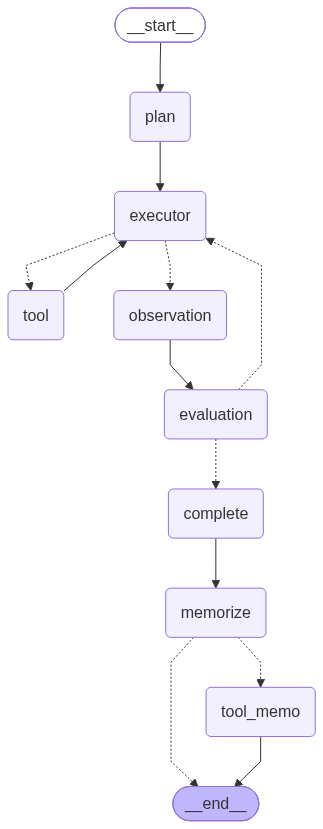

In [14]:

builder= StateGraph(State)


builder.add_node('plan', planner)
builder.add_node('executor',executor)
builder.add_node('evaluation', evaluation)
builder.add_node('tool', tool_node)
builder.add_node('observation',observation)
builder.add_node('complete',complete)
builder.add_node('memorize',memorize)
tool_memo= ToolNode([w_memory])
builder.add_node('tool_memo', tool_memo)

builder.add_edge(START, 'plan')
builder.add_edge('plan','executor')
builder.add_edge('tool', 'executor')
builder.add_edge('observation', 'evaluation')
builder.add_edge('complete','memorize')
builder.add_edge('tool_memo', END)


graph= builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))


In [15]:
print("hello")

hello


In [19]:
user_input= input("Tôi có thể giúp gì bạn: ")
intitial_state= State(
    user_input= user_input ,
    knowledge = r_memory ,
    messages = [HumanMessage(content= user_input)],
    current_time= now,
    plan=[],
    work_memory= [],
    last_work=[],
    confidence=0,
    feedback= ['chưa có feedback'],
    retry=0,
    final_output = '',
    max_call= 4,
    time_call=0
)


Tôi có thể giúp gì bạn:  Xin chào, tôi là Phạm Gia Hưng học ở Đại học Khoa Học Tự Nhiên thành phố Hồ Chí Minh đây. Rất vui được gặp bạn


In [21]:
result = graph.invoke(intitial_state)
print("===============================================RESULT=====================================================")
print(result['final_output'])

 ===============PLANNER================
Plan: # KẾ HOẠCH THỰC HIỆN

## Mục tiêu
Chào đón người dùng và xác định nhu cầu cụ thể để hỗ trợ.

## Các bước thực hiện

1. **Chào đón và giới thiệu bản thân** - Trả lời lời chào, xác nhận đã ghi nhận thông tin cá nhân (Phạm Gia Hưng, sinh viên ĐH Khoa Học Tự Nhiên TP.HCM)

2. **Hỏi nhu cầu hỗ trợ** - Hỏi người dùng muốn được hỗ trợ gì (quản lý lịch trình, lên kế hoạch học tập, ghi nhớ thông tin, v.v.)

3. **Chờ phản hồi** - Dựa vào yêu cầu cụ thể để lập kế hoạch chi tiết hơn (có thể cần dùng tool `w_pd` hoặc `read_pd`)

## Tool cần sử dụng
- **Chưa cần tool** ở bước này (chỉ cần hội thoại)

## Điều kiện hoàn thành
Người dùng trả lời với yêu cầu cụ thể → Chuyển sang lập kế hoạch chi tiết cho yêu cầu đó.

---

**Ghi chú:** Đây là bước khởi đầu. Kế hoạch sẽ được mở rộng khi người dùng nêu rõ mục tiêu cụ thể (ví dụ: "tôi muốn thêm lịch thi vào ngày mai", "xem lịch tuần này", "lập kế hoạch ôn thi", v.v.).
 ===============EXECUTOR================
   

In [8]:
print("my knowledge: ", r_memory())

my knowledge:  Tôi là Javis.



In [23]:
print(r_memory())

Tôi là Javis.




In [18]:
schedule

,content
date,
2026-08-25 21:00:00,Đón bạn gái từ Đà Nẵng về TP.HCM lúc 21:00 tại...


In [24]:
print(result['work_memory'])

[AIMessage(content='Xin chào bạn Hưng! Rất vui được gặp bạn - sinh viên Đại học Khoa Học Tự Nhiên TP.HCM.\n\nBạn cần tôi hỗ trợ gì hôm nay? Tôi có thể giúp bạn:\n- Quản lý lịch trình cá nhân (thêm/xem/sửa lịch)\n- Lên kế hoạch học tập, ôn thi\n- Ghi nhớ các deadline, buổi học, hoạt động ngoại khóa\n- Hay bất cứ việc gì liên quan đến tổ chức thời gian\n\nChỉ cần nói cho tôi biết bạn muốn làm gì nhé! 😊', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 226, 'prompt_tokens': 1675, 'total_tokens': 1901, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 123, 'rejected_prediction_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': 0, 'cached_tokens': 0, 'video_tokens': 0}, 'cost': 0, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 0, 'upstream_inference_prompt_cost': 0, 'upstream_inference_completions_cost': 0}}, 'model_provider': 

In [25]:
print(result['messages'][-1])

content='Tôi đã hiểu yêu cầu của người dùng. Họ giới thiệu mình là Phạm Gia Hưng, sinh viên Đại học Khoa Học Tự Nhiên thành phố Hồ Chí Minh, và cho biết nhu cầu chính của mình bao gồm:\n\n- Quản lý lịch trình cá nhân (thêm/xem/sửa lịch)\n- Lên kế hoạch học tập, ôn thi\n- Ghi nhớ deadline, buổi học, hoạt động ngoại khóa\n- Tổ chức thời gian\n\nĐây là thông tin có giá trị lâu dài cần lưu trong memory, vì nó sẽ giúp tôi hiểu người dùng tốt hơn trong các phiên làm việc sau này mà không cần họ phải nói lại từ đầu.\n\nTôi sẽ lưu thông tin này vào memory một cách ngắn gọn, tập trung vào các fact và preference bền vững.' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 964, 'prompt_tokens': 2136, 'total_tokens': 3100, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 796, 'rejected_prediction_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': 0, '